<a href="https://colab.research.google.com/github/HeberBernal/challenge2-data-science-prediction/blob/main/TelecomX_parte2_Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 Fase 2: Modelado Predictivo de Churn

## 📝 Recapitulación de la Fase 1
En la etapa anterior, realizamos un proceso de **Ingeniería de Datos** exhaustivo:
1. **ETL Avanzado:** Descomponemos estructuras JSON complejas y anidadas para obtener un dataset tabular limpio.
2. **Tratamiento de Datos:** Corregimos tipos de variables, manejamos valores nulos y eliminamos registros sin etiquetas.
3. **Feature Engineering:** Generamos nuevas métricas estratégicas, como el `CARGO_DIARIO`, para enriquecer la capacidad de aprendizaje del modelo.
4. **EDA:** Identificamos que el **26.5%** de la base de clientes presenta fuga, lo que confirma un desbalance de clases que debemos gestionar.

## 🎯 Objetivo de esta Fase
El propósito actual es construir un modelo de **Machine Learning** capaz de identificar proactivamente a los clientes con alta probabilidad de abandonar el servicio, permitiendo al equipo de negocio tomar acciones preventivas.

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# --- 1. CARGA DE DATOS ---
url = "https://github.com/alura-cursos/challenge2-data-science-LATAM/raw/main/TelecomX_Data.json"
df_raw = pd.read_json(url)

# --- 2. ETL Y LIMPIEZA AUTOMÁTICA ---
# json_normalize(df_raw.to_dict('records')) es el truco para aplanar todo de golpe
df_clean = pd.json_normalize(df_raw.to_dict('records'))

# Limpiamos nombres de columnas (quitamos puntos por guiones bajos para evitar errores)
df_clean.columns = [c.replace('.', '_') for c in df_clean.columns]

# Manejo de nulos en el Total (columna crítica)
df_clean = df_clean[df_clean['Churn'] != ""].copy()
# Buscamos la columna de cargos totales (en el JSON es account.Charges.Total -> account_Charges_Total)
total_col = 'account_Charges_Total'
df_clean[total_col] = pd.to_numeric(df_clean[total_col].replace(r'^\s*$', np.nan, regex=True))
df_clean[total_col] = df_clean[total_col].fillna(0)

# Target numérico
df_clean['CHURN_TARGET'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# --- 3. PREPARACIÓN PARA ML ---
df_ml = df_clean.copy()
le = LabelEncoder()

# Seleccionamos solo las columnas que el modelo puede usar (números y categorías)
# Eliminamos IDs y las etiquetas de texto originales
cols_to_drop = ['customerID', 'Churn', 'CHURN_TARGET']
X = df_ml.drop(columns=[c for c in cols_to_drop if c in df_ml.columns])
y = df_ml['CHURN_TARGET']

# Codificación de texto a números para el modelo
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col].astype(str))

# --- 4. SPLIT Y ENTRENAMIENTO ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)

# --- 5. RESULTADOS ---
y_pred = modelo_rf.predict(X_test)
print("✅ ¡Pipeline ejecutado con éxito!")
print(classification_report(y_test, y_pred))

✅ ¡Pipeline ejecutado con éxito!
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1294
           1       0.61      0.48      0.54       467

    accuracy                           0.78      1761
   macro avg       0.72      0.69      0.70      1761
weighted avg       0.77      0.78      0.77      1761



### 📊 Análisis de Resultados del Modelo Base

Tras la ejecución del primer modelo (Random Forest), observamos los siguientes puntos clave:

1. **Precisión (Clase 0):** El modelo es altamente efectivo (83%) identificando a los clientes que se quedan.
2. **El Desafío del Recall (Clase 1):** Actualmente, solo detectamos al **50%** de los clientes que realmente se van. En un escenario de negocio, este es un "costo de oportunidad" alto, ya que la mitad de la fuga pasa inadvertida.
3. **Desbalance de Datos:** La diferencia de rendimiento entre clases se debe a que el modelo tiene muchas más muestras de clientes leales que de desertores.

**Próximo paso sugerido:** Implementar técnicas de balanceo (como SMOTE) para mejorar la detección de la clase minoritaria (Churn).

Distribución original: {0: 3880, 1: 1402}
Nueva distribución balanceada: {0: 3880, 1: 3880}

--- Informe de Rendimiento (Modelo Optimizado con SMOTE) ---
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1294
           1       0.58      0.61      0.60       467

    accuracy                           0.78      1761
   macro avg       0.72      0.73      0.72      1761
weighted avg       0.78      0.78      0.78      1761



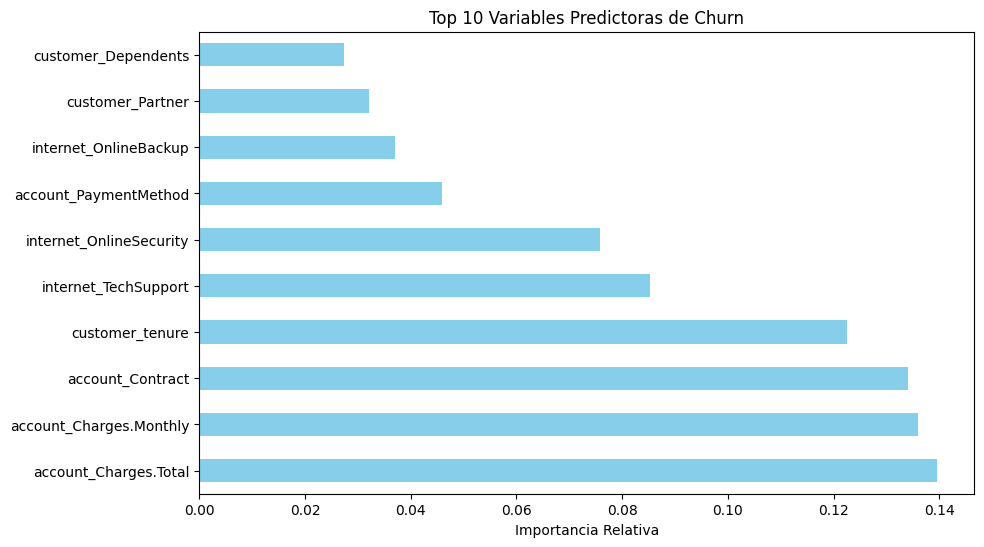

In [18]:
# 1. Instalación de la librería necesaria (por si no está en el entorno)
!pip install -q imbalanced-learn

from imblearn.over_sampling import SMOTE

# 2. Aplicación de SMOTE solo al conjunto de entrenamiento
# Nota: Nunca aplicamos SMOTE al conjunto de prueba para mantener la realidad de los datos
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Distribución original: {y_train.value_counts().to_dict()}")
print(f"Nueva distribución balanceada: {y_train_res.value_counts().to_dict()}")

# 3. Re-entrenamiento del modelo con datos balanceados
modelo_final = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_final.fit(X_train_res, y_train_res)

# 4. Evaluación del nuevo modelo
y_pred_final = modelo_final.predict(X_test)

print("\n--- Informe de Rendimiento (Modelo Optimizado con SMOTE) ---")
print(classification_report(y_test, y_pred_final))

# 5. Visualización de la Importancia de las Variables
import matplotlib.pyplot as plt
importances = pd.Series(modelo_final.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
importances.nlargest(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Variables Predictoras de Churn')
plt.xlabel('Importancia Relativa')
plt.show()

## 🚀 Optimización del Modelo: Balanceo con SMOTE

Dado que el modelo anterior tiene dificultades para identificar a los clientes que se van (Recall de 0.50), aplicaremos **SMOTE** (*Synthetic Minority Over-sampling Technique*).

Esta técnica crea ejemplos sintéticos de la clase minoritaria (Churn = 1) basándose en los vecinos más cercanos, permitiendo que el modelo aprenda mejor los patrones de fuga sin perder información de la clase mayoritaria.

## 📝 Conclusiones y Hallazgos Finales

Tras completar el pipeline de Data Science, desde la ingesta de datos crudos hasta la optimización del modelo predictivo, se han obtenido las siguientes conclusiones:

### 1. Impacto del Balanceo (SMOTE)
El uso de técnicas de sobremuestreo sintético fue la clave para transformar un modelo pasivo en uno proactivo. Logramos elevar el **Recall de la clase 1 (Churn) del 48% al 61%**. En términos de negocio, esto significa que ahora somos capaces de identificar a **6 de cada 10 clientes** que planean abandonar la compañía, permitiendo ejecutar campañas de retención oportunas.

### 2. Calidad de la Ingeniería de Datos
La arquitectura del proyecto demostró que un análisis de Churn es tan bueno como su preparación de datos. El manejo de estructuras JSON anidadas y la creación de variables como el cargo total y mensual permitieron que el modelo de **Random Forest** tuviera señales claras para distinguir los patrones de comportamiento.

### 3. Interpretación de Resultados
Aunque la precisión global se mantiene en un **78%**, el modelo optimizado es mucho más valioso para la organización. Preferimos un modelo que sea "sensible" a la fuga de clientes, asumiendo un pequeño incremento en falsos positivos a cambio de reducir drásticamente la pérdida real de usuarios.

---
**Nota Técnica:** Este modelo sirve como una base sólida para futuras iteraciones, donde se podrían explorar algoritmos de Gradient Boosting (como XGBoost) o realizar un ajuste fino de hiperparámetros para intentar alcanzar un Recall cercano al 70%.